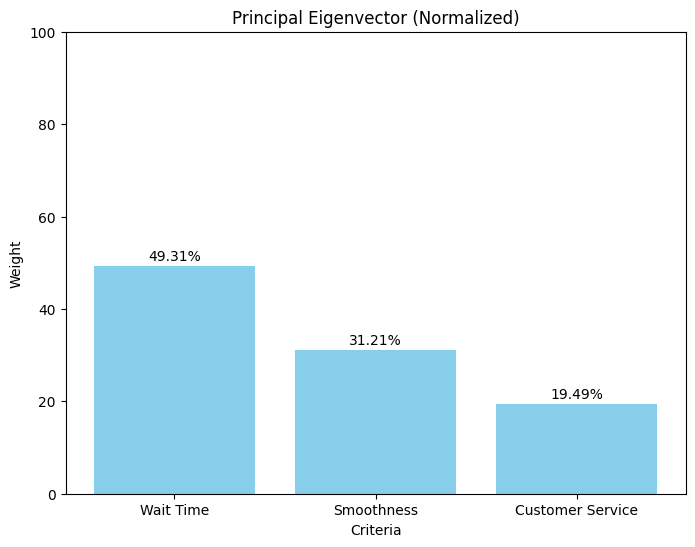

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Define the pairwise comparison matrix for criteria
criteria_matrix = np.array([
    [1, 17/9, 2],    # Wait Time vs. Smoothness vs. Customer Service
    [9/17, 1, 2 + 1/2],    
    [1/2, 2/5, 1]
])

# Normalize the criteria matrix
criteria_matrix_normalized = criteria_matrix / np.sum(criteria_matrix, axis=0, keepdims=True)

# Calculate the principal eigenvector
eig_val, eig_vec = np.linalg.eig(criteria_matrix_normalized)
principal_eigvec = eig_vec[:, np.argmax(eig_val)].real

# Convert the weights to percentages
weights_percentage = principal_eigvec * 100

# Plot the bar chart for the principal eigenvector with percentages
criteria_labels = ['Wait Time', 'Smoothness', 'Customer Service']
plt.figure(figsize=(8, 6))
bars = plt.bar(criteria_labels, principal_eigvec, color='skyblue')
for bar, weight in zip(bars, weights_percentage):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{weight:.2f}%", ha='center', va='bottom')
plt.title("Principal Eigenvector (Normalized)")
plt.xlabel("Criteria")
plt.ylabel("Weight")
plt.ylim(0, 1)
plt.show()




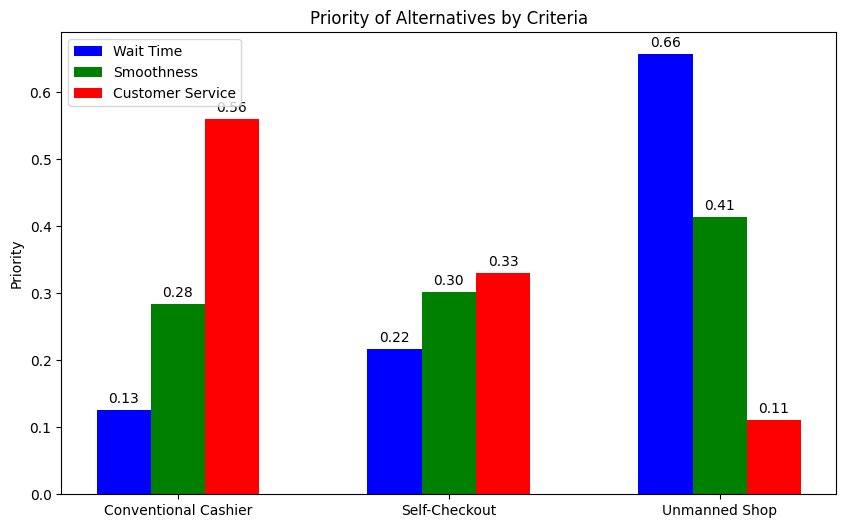

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Define the sub-criteria pairwise comparison matrices for each alternative
wait_time_matrix = np.array([
    [1, 1/2, 2/9],    # Conventional Cashier vs. Self-Checkout vs. Unmanned Shop
    [2, 1, 2/7],
    [4+1/2, 3+1/2, 1]
])

smoothness_matrix = np.array([
    [1, 7/9, 5/6],
    [9/7, 1, 3/5],
    [1 + 1/5, 1 + 2/3, 1]
])

customer_service_matrix = np.array([
    [1, 1 + 5/7, 5],
    [7/12, 1, 3],
    [1/5, 1/3, 1]
])

# Calculate the principal normalized vector for each matrix
wait_time_eig_val, wait_time_eig_vec = np.linalg.eig(wait_time_matrix)
wait_time_max_eig_val_index = np.argmax(wait_time_eig_val)
wait_time_priority_vector = wait_time_eig_vec[:, wait_time_max_eig_val_index] / np.sum(wait_time_eig_vec[:, wait_time_max_eig_val_index].real)

smoothness_eig_val, smoothness_eig_vec = np.linalg.eig(smoothness_matrix)
smoothness_max_eig_val_index = np.argmax(smoothness_eig_val)
smoothness_priority_vector = smoothness_eig_vec[:, smoothness_max_eig_val_index] / np.sum(smoothness_eig_vec[:, smoothness_max_eig_val_index].real)

customer_service_eig_val, customer_service_eig_vec = np.linalg.eig(customer_service_matrix)
customer_service_max_eig_val_index = np.argmax(customer_service_eig_val)
customer_service_priority_vector = customer_service_eig_vec[:, customer_service_max_eig_val_index] / np.sum(customer_service_eig_vec[:, customer_service_max_eig_val_index].real)

# Define labels for the alternatives
alternatives = ['Conventional Cashier', 'Self-Checkout', 'Unmanned Shop']

# Plotting the bar graph
x = np.arange(len(alternatives))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

wait_time_bar = ax.bar(x - width, np.abs(wait_time_priority_vector.real), width, label='Wait Time', color='blue')
smoothness_bar = ax.bar(x, np.abs(smoothness_priority_vector.real), width, label='Smoothness', color='green')
customer_service_bar = ax.bar(x + width, np.abs(customer_service_priority_vector.real), width, label='Customer Service', color='red')

ax.set_ylabel('Priority')
ax.set_title('Priority of Alternatives by Criteria')
ax.set_xticks(x)
ax.set_xticklabels(alternatives)
ax.legend()

# Add text annotation for weights
def add_bar_annotation(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate('%.2f' % height,
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_bar_annotation(wait_time_bar)
add_bar_annotation(smoothness_bar)
add_bar_annotation(customer_service_bar)

plt.show()


Conventional Cashier: 0.28
Self-Checkout: 0.30
Unmanned Shop: 0.42


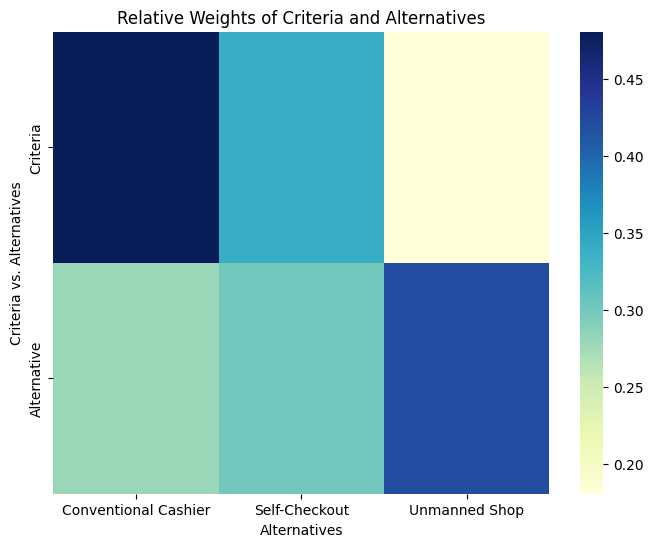

In [67]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define the pairwise comparison matrix for criteria
criteria_matrix = np.array([
    [1, 17/9, 2],    # Wait Time vs. Smoothness vs. Customer Service
    [9/17, 1, 2 + 1/2],    
    [1/2, 2/5, 1]
])

# Define the sub-criteria pairwise comparison matrices for each alternative
wait_time_matrix = np.array([
    [1, 1/2, 2/9],    # Conventional Cashier vs. Self-Checkout vs. Unmanned Shop
    [2, 1, 2/7],
    [4+1/2, 3+1/2, 1]
])

smoothness_matrix = np.array([
    [1, 7/9, 5/6],
    [9/7, 1, 3/5],
    [1 + 1/5, 1 + 2/3, 1]
])

customer_service_matrix = np.array([
    [1, 1 + 5/7, 5],
    [7/12, 1, 3],
    [1/5, 1/3, 1]
])

# Calculate the priority vectors for criteria
criteria_eig_val, criteria_eig_vec = np.linalg.eig(criteria_matrix)
max_eig_val_index = np.argmax(criteria_eig_val)
criteria_priority_vector = criteria_eig_vec[:, max_eig_val_index] / np.sum(criteria_eig_vec[:, max_eig_val_index])

# Normalize the eigenvector for criteria
criteria_priority_vector /= np.sum(criteria_priority_vector.real)

# Calculate the priority vectors for sub-criteria for each alternative
wait_time_eig_val, wait_time_eig_vec = np.linalg.eig(wait_time_matrix)
wait_time_max_eig_val_index = np.argmax(wait_time_eig_val)
wait_time_priority_vector = wait_time_eig_vec[:, wait_time_max_eig_val_index] / np.sum(wait_time_eig_vec[:, wait_time_max_eig_val_index])

smoothness_eig_val, smoothness_eig_vec = np.linalg.eig(smoothness_matrix)
smoothness_max_eig_val_index = np.argmax(smoothness_eig_val)
smoothness_priority_vector = smoothness_eig_vec[:, smoothness_max_eig_val_index] / np.sum(smoothness_eig_vec[:, smoothness_max_eig_val_index])

customer_service_eig_val, customer_service_eig_vec = np.linalg.eig(customer_service_matrix)
customer_service_max_eig_val_index = np.argmax(customer_service_eig_val)
customer_service_priority_vector = customer_service_eig_vec[:, customer_service_max_eig_val_index] / np.sum(customer_service_eig_vec[:, customer_service_max_eig_val_index])

# Normalize the eigenvectors for sub-criteria
wait_time_priority_vector /= np.sum(wait_time_priority_vector.real)
smoothness_priority_vector /= np.sum(smoothness_priority_vector.real)
customer_service_priority_vector /= np.sum(customer_service_priority_vector.real)

# Define the relative weights of criteria
criteria_labels = ['Wait Time', 'Smoothness', 'Customer Service']
criteria_weights = criteria_priority_vector.real

# Calculate the relative weights of alternatives
alternative_weights = {
    'Conventional Cashier': wait_time_priority_vector[0].real * smoothness_priority_vector[0].real * customer_service_priority_vector[0].real,
    'Self-Checkout': wait_time_priority_vector[1].real * smoothness_priority_vector[1].real * customer_service_priority_vector[1].real,
    'Unmanned Shop': wait_time_priority_vector[2].real * smoothness_priority_vector[2].real * customer_service_priority_vector[2].real
}

# Normalize the alternative weights
total_alternative_weight = sum(alternative_weights.values())
for alternative in alternative_weights:
    alternative_weights[alternative] /= total_alternative_weight

# Print the combined weights for each alternative
for alternative, weight in alternative_weights.items():
    print(f"{alternative}: {weight:.2f}")


# Convert to a DataFrame for seaborn heatmap
data = np.array([
    criteria_weights,
    [alternative_weights['Conventional Cashier'], alternative_weights['Self-Checkout'], alternative_weights['Unmanned Shop']]
])
df = pd.DataFrame(data, columns=['Conventional Cashier', 'Self-Checkout', 'Unmanned Shop'], index=['Criteria', 'Alternative'])

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df, cmap="YlGnBu", fmt=".2f")
plt.title("Relative Weights of Criteria and Alternatives")
plt.xlabel("Alternatives")
plt.ylabel("Criteria vs. Alternatives")
plt.show()
